# 06. FX 확장 (tau_star = 3, 2 quantile)

- G10 통화쌍 21개에 동일 방법 적용 (여기서는 synthetic FX panel 사용;
  `data/raw/fx_prices.csv` 가 있으면 해당 데이터 사용)
- STS / MTS / FT 일반화 오차 비교 (논문 Figure 8)
- 2 quantile long-short, 매 3영업일 리밸런싱, reverse trade 제한 없음, offset 3개 앙상블 (논문 Figure 9)

이 노트북은 self-contained 이다 (01~04 함수 복사).

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: FX 가격 데이터 로드 (또는 synthetic 생성)

In [2]:
def generate_synthetic_prices(
    n_assets=100,
    n_days=3000,
    n_factors=5,
    seed=42,
    factor_vol=0.010,
    idio_vol=0.012,
    mispricing_vol=0.009,
    mispricing_rho=0.95,
    drift=0.0002,
    start="2010-01-04",
    asset_names=None,
):
    # 팩터 구조 + 평균회귀 미스프라이싱을 갖는 synthetic price panel.
    # log(p_it) = drift 누적 + (B f_t) 누적 + idio 누적 + m_it
    # m_it 은 AR(1) 평균회귀 -> 양(+)의 abnormal return 이후 반대 방향 수익률이 나오도록 설계
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, periods=n_days)
    if asset_names is None:
        asset_names = [f"A{i:03d}" for i in range(n_assets)]
    assert len(asset_names) == n_assets

    # 팩터 로딩: 첫 팩터는 시장 팩터(로딩 평균 1), 나머지는 스타일 팩터
    B = np.zeros((n_assets, n_factors))
    B[:, 0] = rng.normal(1.0, 0.3, n_assets)
    if n_factors > 1:
        B[:, 1:] = rng.normal(0.0, 0.5, (n_assets, n_factors - 1))

    f_vol = np.full(n_factors, factor_vol * 0.5)
    f_vol[0] = factor_vol
    f = rng.normal(0.0, 1.0, (n_days, n_factors)) * f_vol

    idio = rng.normal(0.0, idio_vol, (n_days, n_assets))

    eta = rng.normal(0.0, mispricing_vol, (n_days, n_assets))
    m = np.zeros((n_days, n_assets))
    for t in range(1, n_days):
        m[t] = mispricing_rho * m[t - 1] + eta[t]

    fundamental = drift + f @ B.T + idio          # 일간 log 수익률(펀더멘털)
    log_price = np.cumsum(fundamental, axis=0) + m
    prices = 100.0 * np.exp(log_price)
    return pd.DataFrame(prices, index=dates, columns=asset_names)

In [3]:
FX_PAIRS = [
    "EURUSD", "USDJPY", "GBPUSD", "AUDUSD", "NZDUSD", "USDCAD", "USDCHF",
    "USDNOK", "USDSEK", "EURJPY", "EURGBP", "EURCHF", "GBPJPY", "AUDJPY",
    "CADJPY", "CHFJPY", "EURAUD", "EURCAD", "AUDNZD", "NZDJPY", "GBPCHF",
]

FX_CSV = RAW_DIR / "fx_prices.csv"
if FX_CSV.exists():
    long_df = pd.read_csv(FX_CSV, parse_dates=["date"])
    fx_prices = long_df.pivot(index="date", columns="asset", values="close").sort_index()
else:
    # FX: 변동성 작고, 미스프라이싱 평균회귀가 빠른 (rho=0.8, 반감기 약 3일) synthetic panel
    fx_prices = generate_synthetic_prices(
        n_assets=21, n_days=1800, n_factors=3, seed=SEED + 1,
        factor_vol=0.004, idio_vol=0.004,
        mispricing_vol=0.004, mispricing_rho=0.8,
        drift=0.0, asset_names=FX_PAIRS,
    )
print("FX panel:", fx_prices.shape)

FX panel: (1800, 21)


## Cell 2: tau별 수익률 및 정규화 (tau = 1..3)

In [4]:
def compute_returns(prices: pd.DataFrame, tau: int) -> pd.DataFrame:
    # r_i,tau(t) = (p_i(t) - p_i(t - tau)) / p_i(t - tau)
    return prices.pct_change(periods=tau)


def cross_section_scale(returns: pd.DataFrame) -> pd.Series:
    # sigma_tau(t) = std({r_i,tau(t) | i = 1..N})
    scale = returns.std(axis=1, skipna=True)
    return scale.replace(0, np.nan)


def normalize_returns(returns: pd.DataFrame, scale: pd.Series = None) -> pd.DataFrame:
    # r_dagger_tau(t) = r_tau(t) / sigma_tau(t)
    if scale is None:
        scale = cross_section_scale(returns)
    return returns.div(scale, axis=0)

In [5]:
TAU_STAR = 3
TAU_MAX = TAU_STAR

returns_by_tau = {tau: compute_returns(fx_prices, tau) for tau in range(1, TAU_MAX + 1)}
sigma_by_tau = {tau: cross_section_scale(r) for tau, r in returns_by_tau.items()}
norm_by_tau = {tau: normalize_returns(r, sigma_by_tau[tau]) for tau, r in returns_by_tau.items()}
dates = fx_prices.index

In [6]:
LOOKBACK = 1200  # 논문: 타임스케일당 학습 샘플 수 고정


def build_train_positions(t_pos: int, tau: int, lookback: int = LOOKBACK) -> list:
    # t_train_tau(t) = { t-(tau-1)-1, ..., t-(tau-1)-lookback }
    # 현재 시점 수익률과 기간이 겹치는 최근 tau-1개 시점을 제외해 정보 누수를 방지
    end = t_pos - (tau - 1)          # exclusive
    start = end - lookback
    if start < tau:
        raise ValueError(f"t_pos={t_pos}, tau={tau}: 학습 구간이 데이터 범위를 벗어남")
    return list(range(start, end))


def valid_assets(norm_by_tau: dict, t_pos: int, tau_star: int, lookback: int = LOOKBACK) -> list:
    # 학습 구간 + 현재 시점 모두에서 결측이 없는 자산만 사용 (날짜별 investable universe)
    ok = None
    for tau in range(1, tau_star + 1):
        pos = build_train_positions(t_pos, tau, lookback) + [t_pos]
        good = norm_by_tau[tau].iloc[pos].notna().all(axis=0)
        ok = good if ok is None else (ok & good)
    return list(ok.index[ok])


def extract_matrix(norm_returns: pd.DataFrame, positions: list, assets: list) -> np.ndarray:
    X = norm_returns.iloc[positions][assets].to_numpy(dtype=np.float32)
    if np.isnan(X).any():
        raise ValueError("학습 행렬에 NaN 존재 - universe 처리 필요")
    return X


def build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # STS: tau = tau_star 만 사용
    pos = build_train_positions(t_pos, tau_star, lookback)
    return extract_matrix(norm_by_tau[tau_star], pos, assets)


def build_mts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # MTS: tau = 1..tau_star 전부 사용 -> 샘플 수 = lookback * tau_star
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star + 1)
    ]
    return np.vstack(mats)


def build_ft_datasets(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # FT: tau = 1..tau_star-1 로 pre-train 후 tau_star 로 fine-tune
    X_ft = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback)
    if tau_star == 1:
        return None, X_ft
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star)
    ]
    return np.vstack(mats), X_ft



class AutoEncoder(nn.Module):
    # Input(N) -> Dense(M, middle_activation) -> Dense(N, linear),  M = N * C
    def __init__(self, n_assets, compression_ratio=0.5, middle_activation="linear"):
        super().__init__()
        n_hidden = max(1, int(n_assets * compression_ratio))
        act = nn.Identity() if middle_activation == "linear" else nn.Tanh()
        self.encoder = nn.Sequential(nn.Linear(n_assets, n_hidden), act)
        self.decoder = nn.Linear(n_hidden, n_assets)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)



def train_autoencoder(X_train: np.ndarray, config: dict, model: nn.Module = None) -> nn.Module:
    device = config["device"]
    torch.manual_seed(config["seed"])
    if model is None:
        model = AutoEncoder(
            X_train.shape[1],
            config["compression_ratio"],
            config["middle_activation"],
        ).to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
    loss_fn = nn.MSELoss()
    X = torch.tensor(X_train, dtype=torch.float32, device=device)
    n, bs = X.shape[0], config["batch_size"]
    gen = torch.Generator().manual_seed(config["seed"])
    for _ in range(config["epochs"]):
        perm = torch.randperm(n, generator=gen).to(device)
        for i in range(0, n, bs):
            xb = X[perm[i : i + bs]]
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            opt.step()
    return model


def pretrain_and_finetune(X_pre, X_ft, config):
    if X_pre is None:
        return train_autoencoder(X_ft, config)
    model = train_autoencoder(X_pre, config)
    return train_autoencoder(X_ft, config, model=model)


def reconstruct(model: nn.Module, X: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32, device=device))
    return out.cpu().numpy()


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [7]:
def compute_abnormal_return(realized: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    # epsilon_i = r_i - r_hat_i
    return realized - reconstructed


def compute_asset_reconstruction_rmse(X_train, X_hat_train) -> np.ndarray:
    # xi_i = sqrt(mean_t((r_i(t') - r_hat_i(t'))^2))  (tau_star 학습 데이터 기준)
    return np.sqrt(np.mean((X_train - X_hat_train) ** 2, axis=0))


def standardize_abnormal_return(epsilon, xi) -> np.ndarray:
    # epsilon_dagger_i = epsilon_i / xi_i
    return epsilon / xi


def assign_quantiles(eps_dagger: pd.Series, n_quantiles: int) -> pd.Series:
    # 1 = epsilon_dagger 최저 (가장 저평가) ... n = 최고 (가장 고평가)
    ranks = eps_dagger.rank(method="first")
    return pd.qcut(ranks, n_quantiles, labels=False).astype(int) + 1


def apply_reverse_trade_restriction(long_cand, short_cand, prev_long, prev_short):
    # 직전 리밸런싱 long -> 이번 short 후보 제외 / 직전 short -> 이번 long 후보 제외
    long_final = [a for a in long_cand if a not in prev_short]
    short_final = [a for a in short_cand if a not in prev_long]
    return long_final, short_final



def compute_signal(t_pos, tau_star, norm_by_tau, config):
    # 기준 시점 t 에서 MTS 오토인코더 학습 후 epsilon_dagger 계산
    assets = valid_assets(norm_by_tau, t_pos, tau_star)
    X_mts = build_mts_dataset(t_pos, tau_star, norm_by_tau, assets)
    model = train_autoencoder(X_mts, config)

    # xi: tau_star 스케일 학습 데이터의 자산별 reconstruction RMSE
    X_ts = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets)
    xi = compute_asset_reconstruction_rmse(X_ts, reconstruct(model, X_ts))

    x_now = norm_by_tau[tau_star].iloc[t_pos][assets].to_numpy(dtype=np.float32)
    x_hat = reconstruct(model, x_now[None, :])[0]
    eps = compute_abnormal_return(x_now, x_hat)
    eps_dagger = standardize_abnormal_return(eps, xi)
    return pd.Series(eps_dagger, index=assets)

## Cell 3: STS / MTS / FT RMSE 비교 (논문 Figure 8 대응)

In [8]:
SMOKE = True

CONFIG = {
    "epochs": 30 if SMOKE else 50,
    "batch_size": 128,
    "lr": 1e-3,
    "compression_ratio": 0.5,
    "middle_activation": "linear",
    "seed": SEED,
    "device": DEVICE,
}

N_TEST_DATES = 6 if SMOKE else 60
MIN_POS = LOOKBACK + 2 * TAU_STAR + 5
TEST_END = len(dates) - 300
test_positions = np.linspace(MIN_POS, TEST_END, N_TEST_DATES).astype(int).tolist()

records = []
for t_pos in test_positions:
    assets = valid_assets(norm_by_tau, t_pos, TAU_STAR)
    x_test = norm_by_tau[TAU_STAR].iloc[t_pos][assets].to_numpy(dtype=np.float32)[None, :]

    m = train_autoencoder(build_sts_dataset(t_pos, TAU_STAR, norm_by_tau, assets), CONFIG)
    records.append({"date": dates[t_pos].date().isoformat(), "method": "STS",
                    "rmse": compute_rmse(x_test, reconstruct(m, x_test))})

    m = train_autoencoder(build_mts_dataset(t_pos, TAU_STAR, norm_by_tau, assets), CONFIG)
    records.append({"date": dates[t_pos].date().isoformat(), "method": "MTS",
                    "rmse": compute_rmse(x_test, reconstruct(m, x_test))})

    X_pre, X_ft = build_ft_datasets(t_pos, TAU_STAR, norm_by_tau, assets)
    m = pretrain_and_finetune(X_pre, X_ft, CONFIG)
    records.append({"date": dates[t_pos].date().isoformat(), "method": "FT",
                    "rmse": compute_rmse(x_test, reconstruct(m, x_test))})
    print(dates[t_pos].date(), "완료", flush=True)

df_fx_gen = pd.DataFrame(records)
df_fx_gen.to_csv(RESULT_DIR / "fx_generalization_error.csv", index=False)
df_fx_gen.groupby("method")["rmse"].mean().round(4)

2014-08-26 완료


2014-11-13 완료


2015-02-03 완료


2015-04-24 완료


2015-07-15 완료


2015-10-05 완료


method
FT     0.7057
MTS    0.7085
STS    0.7245
Name: rmse, dtype: float64

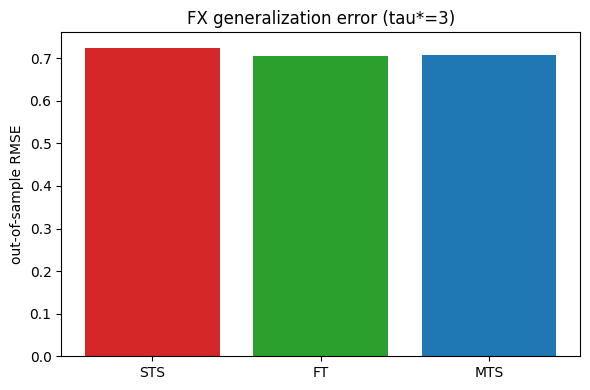

In [9]:
fx_agg = df_fx_gen.groupby("method")["rmse"].mean().reindex(["STS", "FT", "MTS"])
plt.figure(figsize=(6, 4))
plt.bar(fx_agg.index, fx_agg.values, color=["tab:red", "tab:green", "tab:blue"])
plt.ylabel("out-of-sample RMSE")
plt.title(f"FX generalization error (tau*={TAU_STAR})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fx_generalization_error.png", dpi=120)
plt.show()

## Cell 4: 2 quantile long-short 백테스트 (제한 없음)

In [10]:
import time

N_QUANTILES = 2
LONG_Q, SHORT_Q = 1, 2
BACKTEST_DAYS = 240 if SMOKE else 750
OFFSETS = [0, 1, 2]

end_pos = len(dates) - 1 - TAU_STAR
start_pos = end_pos - BACKTEST_DAYS
assert start_pos >= MIN_POS

rows = []
t0 = time.time()
for offset in OFFSETS:
    for t_pos in range(start_pos + offset, end_pos + 1, TAU_STAR):
        eps_dagger = compute_signal(t_pos, TAU_STAR, norm_by_tau, CONFIG)
        q = assign_quantiles(eps_dagger, N_QUANTILES)
        fwd = returns_by_tau[TAU_STAR].iloc[t_pos + TAU_STAR].reindex(eps_dagger.index).astype(float)
        ls = fwd[q.index[q == LONG_Q]].mean() - fwd[q.index[q == SHORT_Q]].mean()
        rows.append({"offset": offset, "date": dates[t_pos], "ls": ls})
    print(f"offset {offset} 완료 ({time.time() - t0:.0f}s)", flush=True)

df_fx_bt = pd.DataFrame(rows)
df_fx_bt.to_csv(RESULT_DIR / "fx_long_short_returns.csv", index=False)
print("리밸런싱 횟수:", len(df_fx_bt))
print("평균 LS (기간당, %%): %.3f" % (df_fx_bt["ls"].mean() * 100))

offset 0 완료 (58s)


offset 1 완료 (115s)


offset 2 완료 (172s)


리밸런싱 횟수: 241
평균 LS (기간당, %): 0.051


## Cell 5: offset 3개 앙상블 그래프 (논문 Figure 9 대응)

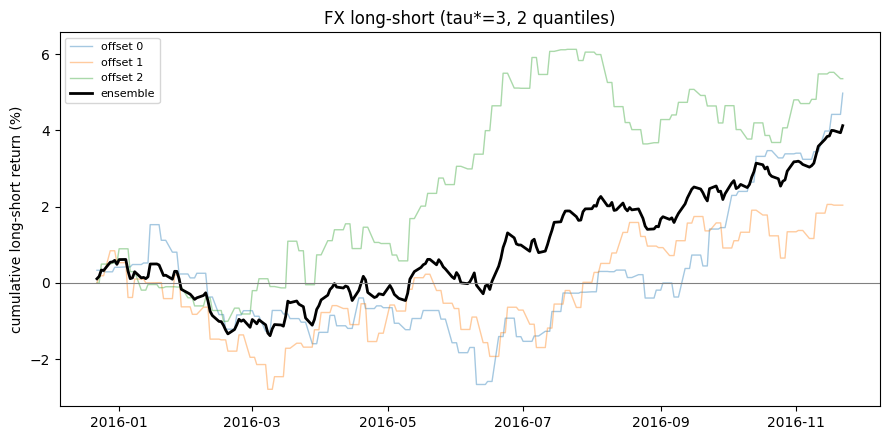

In [11]:
bt_dates = dates[start_pos : end_pos + 1]
curves = {o: g.set_index("date")["ls"].cumsum() for o, g in df_fx_bt.groupby("offset")}
df_c = pd.DataFrame(curves).sort_index().reindex(bt_dates).ffill().fillna(0.0)
ens = df_c.mean(axis=1)

plt.figure(figsize=(9, 4.5))
for o in OFFSETS:
    plt.plot(df_c.index, df_c[o] * 100, alpha=0.4, lw=1, label=f"offset {o}")
plt.plot(ens.index, ens.values * 100, color="k", lw=2, label="ensemble")
plt.axhline(0, color="gray", lw=0.8)
plt.ylabel("cumulative long-short return (%)")
plt.title(f"FX long-short (tau*={TAU_STAR}, 2 quantiles)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fx_long_short_spread.png", dpi=120)
plt.show()